## CIFAR-10 zero-shot classifier with Resnet50
In this notebook, we provide a use-case of our method.
We use a Resnet50 model (pre-trained on ImageNet) and leverage Text-To-Concept to turn it into a zero-shot classifer on CIFAR-10.
This notebook has these sections:
+ <i>Preliminaries</i>: we import required libraries and load transformations.
+ <i>Resnet50</i>: we load the model and implement its necessary functions, enabling us to use `TextToConcept` framework.
+ <i>Linear Aligner</i>: we initiate `TextToConcept` object and train/load its linear aligner.
+ <i>Zero-shot classifier</i>: we use methods implemented in `TextToConcept` and appropriate text prompts to get the zero-shot classifer.
+ <i>Zero-shot performance on CIFAR-10</i>: we load CIFAR-10 and evaluate Resnet50-based zero-shot classifier on it. 


### Preliminaries
In this section, we import the required libraries and initialize standard transformations necessary for loading datasets. It is worth mentioning that certain models require input normalization, while others do not.

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torchvision
import numpy as np
from tqdm import tqdm
from TextToConcept import TextToConcept

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/rodrigopaganini/master/xai/project/Text-to-concept/ViCLIP/viclip_text.py:4: UserWarning: pkg_res

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
print("Using device:", device)

Using device: cpu


In [4]:
# std_transform_without_normalization = torchvision.transforms.Compose([
#     torchvision.transforms.Resize(224),
#     torchvision.transforms.CenterCrop(224),
#     torchvision.transforms.ToTensor()])


# std_transform_with_normalization = torchvision.transforms.Compose([
#     torchvision.transforms.Resize(224),
#     torchvision.transforms.CenterCrop(224),
#     torchvision.transforms.ToTensor(), 
#     torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

### Resnet50
In this part, we load Resnet50 model.
In order to use ``TextToConcept`` framework, model should implement these functions/attributes:
+ ``forward_features(x)`` that takes a tensor as the input and outputs the representation (features) of input $x$ when it is passed through the model.
+ ``get_normalizer`` should be the normalizer that the models uses to preprocess the input. e.g., Resnet18, uses standard ImageNet normalizer.
+ Attribute ``has_normalizer`` should be `True` when normalizer is need for the model.

In [5]:
from transformers import VideoMAEModel
from video_utils import VideoMAETTCTWrapper

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# feature_extractor = VideoMAEVideoProcessor.from_pretrained("MCG-NJU/videomae-small-finetuned-ssv2")  # TODO unnecessary??
videomae_model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
videomae_model = videomae_model.to(device)

model = VideoMAETTCTWrapper(videomae_model, normalizer=torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 8321.31it/s]
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.v_bias       | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED |  | 
decoder.head.bias                                                    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  

### Linear Aligner

<b>Initiating Text-To-Concept Object</b><br>
In this section, we initiate ``TextToConcept`` object which turns the vision encoder (e.g., Resnet50) into a model capable of integrating language and vision. By doing so, we enable the utilization of certain abilities present in vision-language models.

In [6]:
text_to_concept = TextToConcept(model, 'videomae', 'video')

We can either train the aligner or load an existing one.

#### Training Linear Aligner

<b>Loading ImageNet Dataset to Train the Aligner</b><br>
We note that even $20\%$ of ImageNet training samples suffices for training an effective linear aligner. 
We refer to Appendix A of our paper for more details on sample efficiency of linear alignment.

<b>Training the Linear Aligner</b><br>
After loading the object, we need to train the aligner.
+ In order to train the aligner, ``train_linear_aligner`` should be called which obtains representations of the given model (e.g., Resnet50) on ``dset`` as well that of a vision-language model such as CLIP. These representations can also be loaded. Next, this function solves the linear transformation and obtain optimal alignment from model's space to vision-language space.
+ By calling the function ``save_linear_aligner``, linear aliger will be stored which can be utilized later.

<b>Loading the Linear Aligner</b><br>
We can also use an already existing linear aligner, to do so, we use the function ``load_linear_aligner``.

In [7]:
path = 'pretrained_aligners/videomae_base_aligner_k400.pth'
text_to_concept.load_linear_aligner(path, device='cpu')

### Zero-shot Classifier
We note that CIFAR-10 is a <i>$10$-way</i> classification problem. 
We use prompts of the form `a pixelated of {c}` to get appropriate concepts in vision-language space.

In [24]:
from pathlib import Path
import pandas as pd
import json

from video_utils import make_dataset, DivideBy255, CTHWToTCHW, ToTensorTuple
from train_video_aligner import SizedLabeledVideoDataset

from video_utils import load_k400_split, filter_labeled_video_paths_by_labels
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop, Normalize
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler

preprocessing_with_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
            Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

# SSV2_ROOT = Path("datasets/ssv2")
UCF_ROOT = Path("dataset/ucf101")
CLASSES_TO_KEEP = {
    "PlayingGuitar",
    "Surfing",
    "SkateBoarding",
    "BrushingTeeth"
}

idx_class_df = pd.read_csv(UCF_ROOT / "classInd.txt", sep=" ", header=None, names=["class_index", "class_name"])
class_to_idx = dict(
    zip(idx_class_df["class_name"], idx_class_df["class_index"])
)


# labeled_video_paths = load_k400_split(
#     "test",
#     K400_ROOT / "test/1/videos_val",
#     class_to_idx=class_to_idx,
#     labels_path=Path(K400_ROOT / "test/1/kinetics400_val_list_videos.txt")
# )
labeled_video_paths = make_dataset(
            UCF_ROOT / "4/val",
            class_to_idx=class_to_idx,
            extensions={".avi", ".mp4"},
            search_class_subdirs=True,
)
clip_sampler = UniformClipSampler(clip_duration=3.0)

ucf_class_names = ["BrushingTeeth", "PlayingGuitar", "SkateBoarding", "Surfing"]
ucf_text_labels = ["brushing teeth", "playing guitar", "skateboarding", "surfing"]
ucf_prompts = ["a video of someone {}", "someone is {}", "a person is {}"]

old_to_new = {class_to_idx[name]: i for i, name in enumerate(ucf_class_names)}

subset_paths_test = [
    (path, {"label": old_to_new[info["label"]]})
    for path, info in labeled_video_paths
    if info["label"] in old_to_new
]

dset = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths_test,
    clip_sampler=clip_sampler,
    transform=preprocessing_with_normalization,
)

ucf_zeroshot_classifier = text_to_concept.get_zero_shot_classifier(
    ucf_text_labels,
    prompts=ucf_prompts,
)

print(len(dset))

67


In [25]:
ucf_zeroshot_classifier = text_to_concept.get_zero_shot_classifier(ucf_text_labels,
                                                                     prompts=['a pixelated photo of a {}'])

### Zero-shot performance on CIFAR-10
After loading CIFAR-10, we use `cifar_zeroshot_classifier(x)` to get logits of the classification problem when input $x$ is given.

In [26]:
ucf_zeroshot_classifier.model = ucf_zeroshot_classifier.model.to('cpu')
# ucf_zeroshot_classifier.aligner = ucf_zeroshot_classifier.aligner.to('cpu')
# text_to_concept.clip_model = text_to_concept.clip_model.to(device)

In [27]:
ucf_zeroshot_classifier.device = torch.device("cpu")
ucf_zeroshot_classifier.model = ucf_zeroshot_classifier.model.to("cpu")
ucf_zeroshot_classifier.aligner.W = ucf_zeroshot_classifier.aligner.W.to("cpu")
ucf_zeroshot_classifier.aligner.b = ucf_zeroshot_classifier.aligner.b.to("cpu")
ucf_zeroshot_classifier.zeroshot_weights = ucf_zeroshot_classifier.zeroshot_weights.to("cpu")


In [28]:
# Plot confusion matrix for UCF-101 zero-shot classifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

loader = torch.utils.data.DataLoader(dset, batch_size=16, shuffle=False, num_workers=8)
# Collect all predictions and true labels
all_preds = []
all_labels = []
all_names = []
with torch.no_grad():
    for data in tqdm(loader):
        x, y, names = data
        x = x.to(device)
        outputs = ucf_zeroshot_classifier(x).detach().cpu()
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y.numpy())
        all_names.extend(names)


  0%|          | 0/5 [00:00<?, ?it/s]

13it [02:01,  9.34s/it]                      


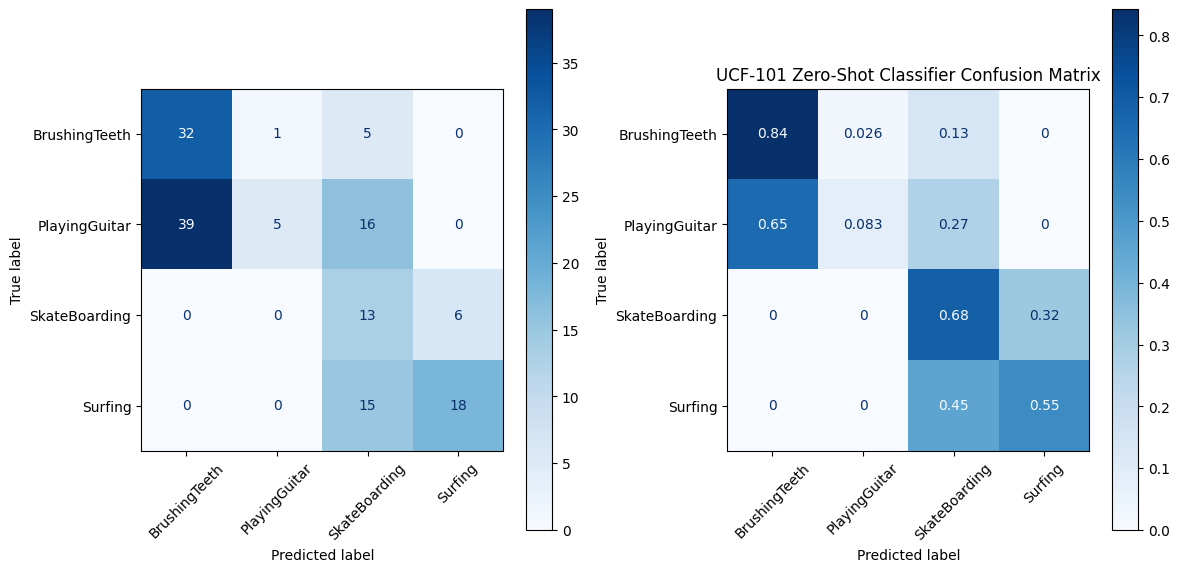

In [29]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ucf_class_names)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ucf_class_names)
fig, ax = plt.subplots(1, 2, figsize=(12,6))
disp.plot(ax=ax[0], cmap='Blues', xticks_rotation=45)
disp_norm.plot(ax=ax[1], cmap='Blues', xticks_rotation=45)
plt.title('UCF-101 Zero-Shot Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

In [30]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
f'VideoMAE Zeroshot Accuracy on UCF-101 {accuracy:.2%}'

'VideoMAE Zeroshot Accuracy on UCF-101 45.33%'

# This classification makes sense